# Importações

In [ ]:
import os
import random

import matplotlib.pyplot as plt
import numpy as np
import shap

from matplotlib.ticker import FuncFormatter
from shap.plots import colors
from sklearn.metrics import root_mean_squared_error
from sklearn.model_selection import TimeSeriesSplit, train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.ensemble import RandomForestRegressor as RF

import pandas as pd

SEEDS = [1000, 2000, 3000, 4000, 5000, 6000, 7000, 8000, 9000, 10000]
N_CLASSES = [2, 3, 4, 5, 6, 7, 8, 9, 10]
K_FOLDS = 5


def reset_seed(rnd_seed):
    os.environ['PYTHONHASHSEED'] = '0'
    random.seed(rnd_seed)
    np.random.seed(rnd_seed)


def calcular_rrmse(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    rmse = root_mean_squared_error(y_true, y_pred)

    mean_y_true = np.mean(y_true)

    rrmse = rmse / mean_y_true
    return rrmse


def formater_thousands(x, pos):
    return f'{x:.2f}'.replace('.', ',')

reset_seed(100)









# Carregar Datasets

In [41]:
df = pd.read_csv("./dados/dados_mesclados.csv", sep=';', decimal='.')
df["DATA"] = pd.to_datetime(df["DATA"], format="%Y-%m-%d")
df

,CONSUMO,DATA,TEMP_MIN_MÉD_MENS,TEMP_MÉD_MIN_MENS,TEMP_MÉD_MÉD_MENS,TEMP_MÉD_MAX_MENS,TEMP_MÉD_ACC_MENS,TEMP_MAX_MÉD_MENS,PRECIPITAÇÃO_MÉD_MENS,TEMP_MIN_MIN_MENS,...,CURSOS_GRAD_VESPERTINO,CURSOS_GRAD_NOTURNO,CURSOS_POS,FÉRIAS,FERIADO,COVID,GREVE,CAMPUS,REGIÃO,ORDEM
0,11400.0,2015-02-28,18.0,22.0,25.0,27.0,692.0,33.0,4.0,18.0,...,0.0,1.428571,1.0,0,3,0,0,ASSIS CHATEAUBRIAND,REGIÃO OESTE,1
1,18427.0,2015-03-31,12.0,19.0,24.0,26.0,729.0,32.0,2.0,12.0,...,0.0,2.000000,1.0,0,0,0,0,ASSIS CHATEAUBRIAND,REGIÃO OESTE,2
2,14274.0,2015-04-30,13.0,19.0,21.0,24.0,640.0,29.0,6.0,13.0,...,0.0,2.000000,1.0,0,1,0,0,ASSIS CHATEAUBRIAND,REGIÃO OESTE,3
3,11987.0,2015-05-31,7.0,11.0,18.0,23.0,557.0,28.0,9.0,7.0,...,0.0,2.000000,1.0,0,0,0,0,ASSIS CHATEAUBRIAND,REGIÃO OESTE,4
4,9006.0,2015-06-30,4.0,10.0,18.0,22.0,542.0,29.0,1.0,4.0,...,0.0,2.000000,1.0,0,1,0,0,ASSIS CHATEAUBRIAND,REGIÃO OESTE,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2378,5640.0,2024-06-30,-0.0,8.0,17.0,20.0,499.0,26.0,1.0,-0.0,...,1.0,1.000000,0.0,0,0,0,30,UNIÃO DA VITÓRIA,REGIÃO SUL,81
2379,11687.0,2024-07-31,1.0,9.0,13.0,18.0,413.0,25.0,6.0,1.0,...,1.0,1.000000,0.0,12,0,0,0,UNIÃO DA VITÓRIA,REGIÃO SUL,82
2380,11129.0,2024-08-31,-3.0,7.0,15.0,21.0,468.0,31.0,1.0,-3.0,...,1.0,1.000000,0.0,0,0,0,0,UNIÃO DA VITÓRIA,REGIÃO SUL,83
2381,9690.0,2024-09-30,10.0,13.0,20.0,24.0,591.0,34.0,3.0,10.0,...,1.0,1.000000,0.0,0,0,0,0,UNIÃO DA VITÓRIA,REGIÃO SUL,84


# Tratamento dos dados
## Simplificação dos valores decimais

In [42]:
# Arredondamento dos dados, pelas casas decimais serem irrelevantes
df = df.round()

# Converte os dados para o tipo inteiro
df[df.drop(columns=["DATA", "CAMPUS", "REGIÃO"]).columns] = df[
    df.drop(columns=["DATA", "CAMPUS", "REGIÃO"]).columns].astype(int)

df

,CONSUMO,DATA,TEMP_MIN_MÉD_MENS,TEMP_MÉD_MIN_MENS,TEMP_MÉD_MÉD_MENS,TEMP_MÉD_MAX_MENS,TEMP_MÉD_ACC_MENS,TEMP_MAX_MÉD_MENS,PRECIPITAÇÃO_MÉD_MENS,TEMP_MIN_MIN_MENS,...,CURSOS_GRAD_VESPERTINO,CURSOS_GRAD_NOTURNO,CURSOS_POS,FÉRIAS,FERIADO,COVID,GREVE,CAMPUS,REGIÃO,ORDEM
0,11400,2015-02-28,18,22,25,27,692,33,4,18,...,0,1,1,0,3,0,0,ASSIS CHATEAUBRIAND,REGIÃO OESTE,1
1,18427,2015-03-31,12,19,24,26,729,32,2,12,...,0,2,1,0,0,0,0,ASSIS CHATEAUBRIAND,REGIÃO OESTE,2
2,14274,2015-04-30,13,19,21,24,640,29,6,13,...,0,2,1,0,1,0,0,ASSIS CHATEAUBRIAND,REGIÃO OESTE,3
3,11987,2015-05-31,7,11,18,23,557,28,9,7,...,0,2,1,0,0,0,0,ASSIS CHATEAUBRIAND,REGIÃO OESTE,4
4,9006,2015-06-30,4,10,18,22,542,29,1,4,...,0,2,1,0,1,0,0,ASSIS CHATEAUBRIAND,REGIÃO OESTE,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2378,5640,2024-06-30,0,8,17,20,499,26,1,0,...,1,1,0,0,0,0,30,UNIÃO DA VITÓRIA,REGIÃO SUL,81
2379,11687,2024-07-31,1,9,13,18,413,25,6,1,...,1,1,0,12,0,0,0,UNIÃO DA VITÓRIA,REGIÃO SUL,82
2380,11129,2024-08-31,-3,7,15,21,468,31,1,-3,...,1,1,0,0,0,0,0,UNIÃO DA VITÓRIA,REGIÃO SUL,83
2381,9690,2024-09-30,10,13,20,24,591,34,3,10,...,1,1,0,0,0,0,0,UNIÃO DA VITÓRIA,REGIÃO SUL,84


## Remoção dos outliers

In [43]:
dataframes = []

for campus, dados in df.groupby("CAMPUS"):
    q1 = dados["CONSUMO"].quantile(0.25)
    q3 = dados["CONSUMO"].quantile(0.75)
    iqr = q3 - q1
    limite_inferior = q1 - 1.5 * iqr
    limite_superior = q3 + 1.5 * iqr

    dados["CONSUMO"] = np.where(dados["CONSUMO"] < limite_inferior, limite_inferior, dados["CONSUMO"])
    dados["CONSUMO"] = np.where(dados["CONSUMO"] > limite_superior, limite_superior, dados["CONSUMO"])

    dataframes.append(dados)

df = pd.concat(dataframes, ignore_index=True)
df.to_csv("./dados/dados_tratados.csv", index=False, sep=";", decimal=".")

df

,CONSUMO,DATA,TEMP_MIN_MÉD_MENS,TEMP_MÉD_MIN_MENS,TEMP_MÉD_MÉD_MENS,TEMP_MÉD_MAX_MENS,TEMP_MÉD_ACC_MENS,TEMP_MAX_MÉD_MENS,PRECIPITAÇÃO_MÉD_MENS,TEMP_MIN_MIN_MENS,...,CURSOS_GRAD_VESPERTINO,CURSOS_GRAD_NOTURNO,CURSOS_POS,FÉRIAS,FERIADO,COVID,GREVE,CAMPUS,REGIÃO,ORDEM
0,11400.0,2015-02-28,18,22,25,27,692,33,4,18,...,0,1,1,0,3,0,0,ASSIS CHATEAUBRIAND,REGIÃO OESTE,1
1,18427.0,2015-03-31,12,19,24,26,729,32,2,12,...,0,2,1,0,0,0,0,ASSIS CHATEAUBRIAND,REGIÃO OESTE,2
2,14274.0,2015-04-30,13,19,21,24,640,29,6,13,...,0,2,1,0,1,0,0,ASSIS CHATEAUBRIAND,REGIÃO OESTE,3
3,11987.0,2015-05-31,7,11,18,23,557,28,9,7,...,0,2,1,0,0,0,0,ASSIS CHATEAUBRIAND,REGIÃO OESTE,4
4,9006.0,2015-06-30,4,10,18,22,542,29,1,4,...,0,2,1,0,1,0,0,ASSIS CHATEAUBRIAND,REGIÃO OESTE,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2378,5640.0,2024-06-30,0,8,17,20,499,26,1,0,...,1,1,0,0,0,0,30,UNIÃO DA VITÓRIA,REGIÃO SUL,81
2379,11687.0,2024-07-31,1,9,13,18,413,25,6,1,...,1,1,0,12,0,0,0,UNIÃO DA VITÓRIA,REGIÃO SUL,82
2380,11129.0,2024-08-31,-3,7,15,21,468,31,1,-3,...,1,1,0,0,0,0,0,UNIÃO DA VITÓRIA,REGIÃO SUL,83
2381,9690.0,2024-09-30,10,13,20,24,591,34,3,10,...,1,1,0,0,0,0,0,UNIÃO DA VITÓRIA,REGIÃO SUL,84


## Normalização

In [44]:
df_normalizado = df.copy()

# Agrupa por campus e aplica o scaler a cada grupo de forma independente
scalers = {}
dataframes = []

for campus, dados in df_normalizado.groupby("CAMPUS"):
    scaler = MinMaxScaler()
    dados[["CONSUMO"]] = scaler.fit_transform(dados[["CONSUMO"]])

    scalers[campus] = scaler
    dataframes.append(dados)

df_normalizado = pd.concat(dataframes, ignore_index=True)

df_normalizado.to_csv("./dados/dados_normalizados.csv", index=False, sep=";", decimal=".")

df_normalizado

,CONSUMO,DATA,TEMP_MIN_MÉD_MENS,TEMP_MÉD_MIN_MENS,TEMP_MÉD_MÉD_MENS,TEMP_MÉD_MAX_MENS,TEMP_MÉD_ACC_MENS,TEMP_MAX_MÉD_MENS,PRECIPITAÇÃO_MÉD_MENS,TEMP_MIN_MIN_MENS,...,CURSOS_GRAD_VESPERTINO,CURSOS_GRAD_NOTURNO,CURSOS_POS,FÉRIAS,FERIADO,COVID,GREVE,CAMPUS,REGIÃO,ORDEM
0,0.502037,2015-02-28,18,22,25,27,692,33,4,18,...,0,1,1,0,3,0,0,ASSIS CHATEAUBRIAND,REGIÃO OESTE,1
1,0.846886,2015-03-31,12,19,24,26,729,32,2,12,...,0,2,1,0,0,0,0,ASSIS CHATEAUBRIAND,REGIÃO OESTE,2
2,0.643078,2015-04-30,13,19,21,24,640,29,6,13,...,0,2,1,0,1,0,0,ASSIS CHATEAUBRIAND,REGIÃO OESTE,3
3,0.530844,2015-05-31,7,11,18,23,557,28,9,7,...,0,2,1,0,0,0,0,ASSIS CHATEAUBRIAND,REGIÃO OESTE,4
4,0.384551,2015-06-30,4,10,18,22,542,29,1,4,...,0,2,1,0,1,0,0,ASSIS CHATEAUBRIAND,REGIÃO OESTE,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2378,0.359224,2024-06-30,0,8,17,20,499,26,1,0,...,1,1,0,0,0,0,30,UNIÃO DA VITÓRIA,REGIÃO SUL,81
2379,1.000000,2024-07-31,1,9,13,18,413,25,6,1,...,1,1,0,12,0,0,0,UNIÃO DA VITÓRIA,REGIÃO SUL,82
2380,0.940871,2024-08-31,-3,7,15,21,468,31,1,-3,...,1,1,0,0,0,0,0,UNIÃO DA VITÓRIA,REGIÃO SUL,83
2381,0.788386,2024-09-30,10,13,20,24,591,34,3,10,...,1,1,0,0,0,0,0,UNIÃO DA VITÓRIA,REGIÃO SUL,84


# Criação das Classes


In [46]:
def mapear_classe(consumo, intervalos_quantils):
    for i, (inicio_intervalo, fim_intervalo) in enumerate(intervalos_quantils):
        if inicio_intervalo <= consumo <= fim_intervalo:
            return i

# Definição individual dos intervalos, com base nos datasets locais
for n_classes in N_CLASSES:
    df_classes = df_normalizado.copy()
    quantiles = np.linspace(0, 1, n_classes + 1)

    dataframes = []
    for campus, dados in df_classes.groupby("CAMPUS"):
        intervalos = dados["CONSUMO"].quantile(quantiles).to_numpy()
        classes = [[intervalos[i], intervalos[i + 1]] for i in range(len(intervalos) - 1)]
        dados["CLASSE"] = dados["CONSUMO"].apply(lambda val: mapear_classe(val, classes)).astype(int)
        dataframes.append(dados)

    df_classes_local = pd.concat(dataframes, ignore_index=True)
    os.makedirs(f"dados/classes/{n_classes} classes", exist_ok=True)
    df_classes_local.to_csv(f"./dados/classes/{n_classes} classes/{n_classes}_classes_normalizadas.csv", index=False,
                            sep=";", decimal=".")


## Análise das Classes

In [47]:
def plot_classes(dados, plot_serie=True):
    plt.figure(figsize=(18, 5))
    plt.rcParams['xtick.labelsize'] = 15
    plt.rcParams['ytick.labelsize'] = 15
    plt.rcParams.update({'font.size': 15})

    for classe, dataset in dados.groupby("CLASSE"):
        inicio = dataset["CONSUMO"].min()
        fim = dataset["CONSUMO"].max()
        plt.fill_between(
            dados["DATA"],
            inicio,
            fim,
            alpha=0.65,
            label=f"Classe {classe} ({inicio:.2f} - {fim:.2f})"
        )
    if plot_serie:
        plt.plot(dados["DATA"], dados["CONSUMO"], label="Consumo", color="black", marker='o')

    plt.xlabel('MESES')
    plt.ylabel('CONSUMO')

    ax = plt.gca()
    ax.yaxis.set_major_formatter(FuncFormatter(formater_thousands))
    ax.set_facecolor('white')
    plt.grid(True, color='white', linestyle="--", linewidth=0.75)
    plt.legend(facecolor='white', framealpha=0.5, bbox_to_anchor=(1.05, 1))
    return plt


def plot_distribuicao_classes(dados):
    distribuicao_classes = dados["CLASSE"].value_counts()

    plt.figure(figsize=(12, 6))
    bars = plt.bar(distribuicao_classes.index, distribuicao_classes.values, color="blue", alpha=0.8)

    for bar in bars:
        altura = bar.get_height()
        plt.text(bar.get_x() + bar.get_width() / 2, altura / 2, f"{int(altura)}",
                 ha="center", va="center", fontsize=12, color="white")

    plt.xlabel("CLASSE", fontsize=14)
    plt.ylabel("QUANTIDADE DE DADOS", fontsize=14)
    plt.xticks(df_classes["CLASSE"].unique(), fontsize=12)
    plt.yticks(fontsize=12)
    plt.grid(axis="y", linestyle="--", alpha=0.7)
    return plt


# Gráficos das classes considerando os intervalos locais
for n_classes in N_CLASSES:
    df_classes = pd.read_csv(f"./dados/classes/{n_classes} classes/{n_classes}_classes_normalizadas.csv", sep=";",
                             decimal=".")
    df_classes["DATA"] = pd.to_datetime(df_classes["DATA"], format="%Y-%m-%d")

    for campus, dados in df_classes.groupby("CAMPUS"):
        dados[['CONSUMO']] = scalers[campus].inverse_transform(dados[['CONSUMO']])
        plt = plot_classes(dados)
        plt.savefig(f"./dados/classes/{n_classes} classes/{n_classes} Classes {campus}.png", bbox_inches='tight')
        plt.close()

        plt = plot_distribuicao_classes(dados)
        plt.savefig(f"./dados/classes/{n_classes} classes/Distribuição {n_classes} Classes {campus}.png",
                    bbox_inches="tight")
        plt.close()

    plt = plot_distribuicao_classes(df_classes)
    plt.savefig(f"./dados/classes/{n_classes} classes/Distribuição {n_classes} _TODOS_.png", bbox_inches="tight")
    plt.close()


# Criação dos Lags
## Regressão

In [48]:
df_normalizado = pd.read_csv("./dados/dados_normalizados.csv", sep=";", decimal=".")
df_normalizado["DATA"] = pd.to_datetime(df_normalizado["DATA"], format="%Y-%m-%d")

dataframes = []

for campus, dados in df_normalizado.sort_values("DATA").groupby("CAMPUS"):
    lags = {f'LAG_{i:02d}': dados['CONSUMO'].shift(i) for i in range(1, 12 + 1)}
    dados = pd.concat([dados, pd.DataFrame(lags)], axis=1)
    dados = dados.dropna()
    dados["ORDEM"] = range(1, len(dados) + 1)
    dataframes.append(dados)

df_normalizado = pd.concat(dataframes, ignore_index=True)
df_normalizado.to_csv("./dados/dados_normalizados_lagados.csv", index=False, sep=";", decimal=".")


## Classificação

In [49]:

for n_classes in N_CLASSES:
    dataframes = []
    df_classes = pd.read_csv(f"./dados/classes/{n_classes} classes/{n_classes}_classes_normalizadas.csv", sep=";",
                             decimal=".")
    for campus, dados in df_classes.sort_values("DATA").groupby("CAMPUS"):
        lags = {f'LAG_{i:02d}': dados['CLASSE'].shift(i) for i in range(1, 12 + 1)}
        dados = pd.concat([dados, pd.DataFrame(lags)], axis=1)
        dados = dados.dropna()
        dados[list(lags.keys())] = dados[list(lags.keys())].astype(int)  # Converte os lags para int
        dados["ORDEM"] = range(1, len(dados) + 1)
        dataframes.append(dados)

    df_classes = pd.concat(dataframes, ignore_index=True)
    df_classes.to_csv(f"./dados/classes/{n_classes} classes/{n_classes}_classes_normalizadas_lagadas.csv", index=False,
                      sep=";", decimal=".")


# Importância das Features

In [10]:
# Considerado apenas o dataset de regressão por conta do SHAP ser mais interpretável em regressão
df_normalizado = pd.read_csv("./dados/dados_normalizados_lagados.csv", sep=";", decimal=".")

shap.initjs()


def calcular_importancia(dados, seed):
    reset_seed(seed)
    x = dados.drop(columns=["CONSUMO", "DATA", "CAMPUS", "REGIÃO"])
    y = dados["CONSUMO"]

    rf = RF(random_state=seed)
    rf.fit(x, y)

    explainer_rf = shap.explainers.TreeExplainer(rf)

    shap_rf = explainer_rf(x)
    importancia = pd.DataFrame(list(zip(x.columns, np.abs(shap_rf.values).mean(0))), columns=["FEATURE", "IMPORTÂNCIA"])
    importancia["IMPORTÂNCIA"] = importancia["IMPORTÂNCIA"].round(15)
    importancia = importancia.sort_values(by="FEATURE")
    importancia = importancia.set_index("FEATURE")
    return importancia


for seed in SEEDS:
    # Calcula a importância individual de cada campus
    importancias = pd.DataFrame(
        index=pd.Index(df_normalizado.drop(columns=["CONSUMO", "DATA", "CAMPUS", "REGIÃO"]).columns, name="FEATURE"))

    for campus, dados in df_normalizado.groupby("CAMPUS"):
        if len(dados) < 100:
            continue
        treino, teste = train_test_split(dados, test_size=12, shuffle=False)
        importancias[[campus]] = calcular_importancia(treino, seed)[
            ["IMPORTÂNCIA"]]  # Usados 2 colchetes para vir com o index

    # Calcula a média das importâncias locais
    importancias["MÉDIA"] = importancias.mean(axis=1)

    # Calcula a importância considerando o dataframe global
    importancias[["TODOS"]] = calcular_importancia(df_normalizado, seed)[["IMPORTÂNCIA"]]

    # Recalcula a media considerando a importância global com peso igual às importâncias locais
    importancias["MÉDIA FINAL"] = importancias[["TODOS", "MÉDIA"]].mean(axis=1)

    importancias = importancias.sort_values(by=["MÉDIA"], ascending=False)
    importancias.to_csv(f"./resultados/features/importancia_regressao SEED {seed}.csv", index=True, sep=";",
                        decimal=".")


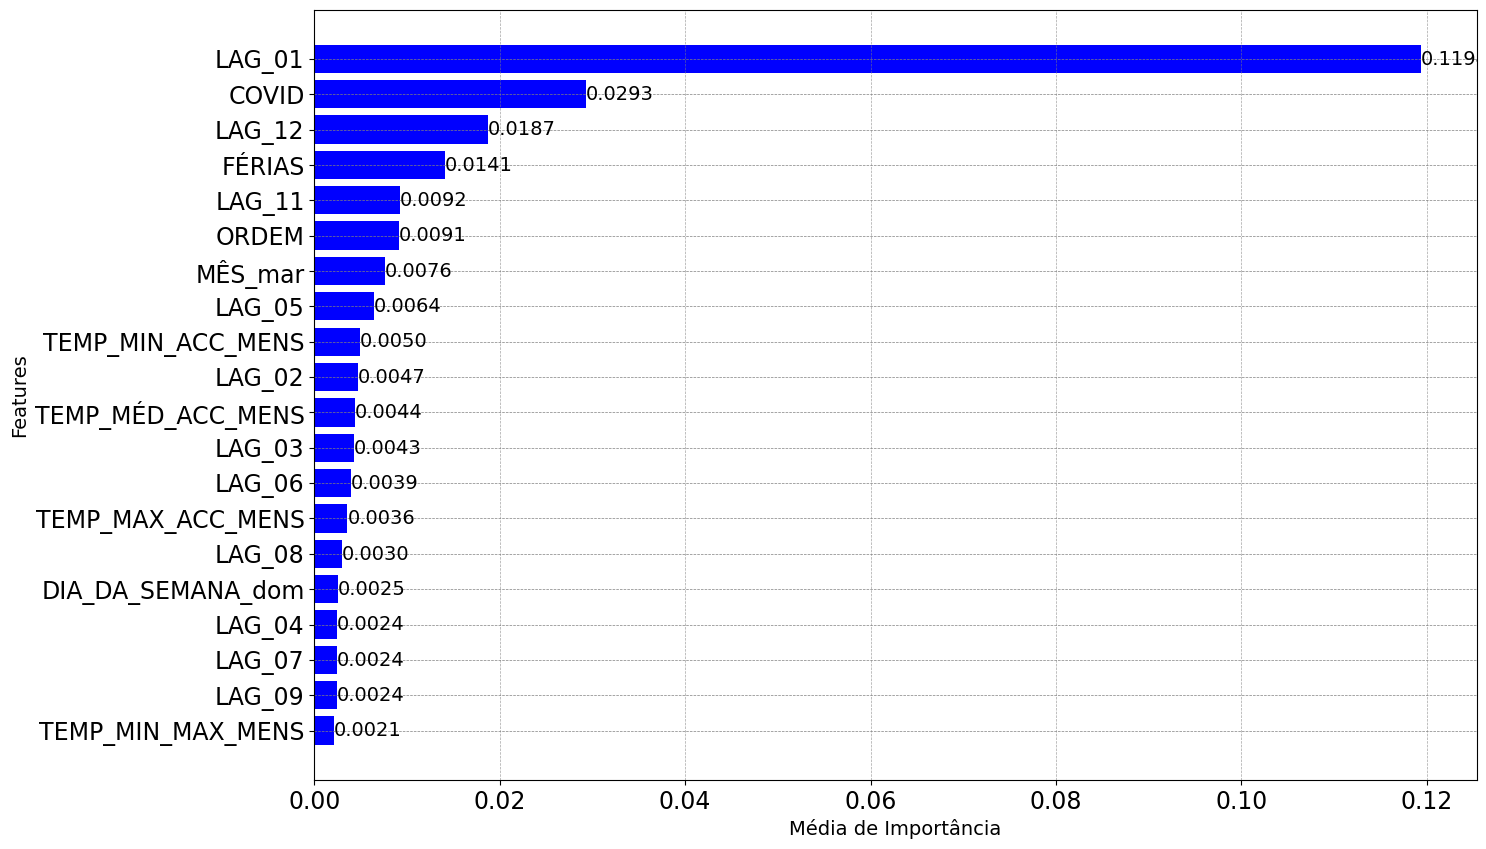

In [7]:
importancias = []
for seed in SEEDS:
    importancia = \
        pd.read_csv(f"./resultados/features/importancia_regressao SEED {seed}.csv", sep=";", decimal=".", header=0,
                    index_col=0)[["MÉDIA FINAL"]]
    importancia = importancia.rename(columns={"MÉDIA FINAL": seed})
    importancias.append(importancia)

importancias = pd.concat(importancias, axis=1)
importancias["MÉDIA FINAL"] = importancias.mean(axis=1)

importancias = importancias.sort_values(by="MÉDIA FINAL", ascending=True)
importancias = importancias.tail(20)

plt.figure(figsize=(15, 10))
plt.rcParams['xtick.labelsize'] = 17
plt.rcParams['ytick.labelsize'] = 17
plt.rcParams.update({'font.size': 14})

bars = plt.barh(importancias.index, importancias["MÉDIA FINAL"], color="blue")

# Adiciona os valores ao lado de cada barra
for bar in bars:
    width = bar.get_width()
    plt.text(width*0.999, bar.get_y() + bar.get_height() / 2, f"{width:.4f}",
             ha='left', va='center', clip_on=True)

# Configurações do gráfico
plt.xlabel("Média de Importância")
plt.ylabel("Features")
plt.grid(axis="x", linestyle="--", alpha=0.7)
ax = plt.gca()
ax.set_facecolor('white')

plt.grid(True, color='grey', linestyle="--", linewidth=0.5)

# Exibe o gráfico
plt.savefig("./resultados/features/MÉDIA DE IMPORTÂNCIAS - REGRESSÃO.png", bbox_inches="tight")
plt.show()


# Remoção de Features

In [2]:
importancias = []
for seed in SEEDS:
    importancia = \
        pd.read_csv(f"./resultados/features/importancia_regressao SEED {seed}.csv", sep=";", decimal=".", header=0,
                    index_col=0)[["MÉDIA FINAL"]]
    importancia = importancia.rename(columns={"MÉDIA FINAL": seed})
    importancias.append(importancia)

importancias = pd.concat(importancias, axis=1)
importancias["MÉDIA FINAL"] = importancias.mean(axis=1)
importancias = importancias.reset_index()

importancias['PERC_IMPORTANCIA'] = importancias['MÉDIA FINAL'] / importancias['MÉDIA FINAL'].sum()
features_iniciais_removidas = importancias[importancias['PERC_IMPORTANCIA'] == 0]

features_sorteio = importancias[importancias['PERC_IMPORTANCIA'] > 0].copy()
pesos_remocao = 1 - features_sorteio["PERC_IMPORTANCIA"]
features_sorteio["PROB_REMOCAO"] = pesos_remocao / pesos_remocao.sum()
features_sorteio



,FEATURE,1000,2000,3000,4000,5000,6000,7000,8000,9000,10000,MÉDIA FINAL,PERC_IMPORTANCIA,PROB_REMOCAO
0,LAG_01,0.119577,0.119737,0.119114,0.118908,0.119456,0.120737,0.119844,0.119227,0.118935,0.118634,0.119417,0.408567,0.006429
1,COVID,0.028695,0.028655,0.030472,0.030566,0.028653,0.029157,0.029482,0.028997,0.029365,0.029324,0.029337,0.100371,0.009779
2,LAG_12,0.018744,0.018240,0.018944,0.018976,0.019518,0.018854,0.018813,0.018393,0.018462,0.018320,0.018726,0.064070,0.010173
3,ORDEM,0.009320,0.009277,0.008870,0.009244,0.009312,0.008113,0.009020,0.009152,0.009266,0.009818,0.009139,0.031268,0.010530
4,FÉRIAS,0.013635,0.014587,0.013766,0.014068,0.013885,0.014340,0.013932,0.014207,0.014271,0.014092,0.014078,0.048167,0.010346
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
92,CAMPUS_PITANGA,0.000064,0.000048,0.000049,0.000056,0.000056,0.000058,0.000044,0.000046,0.000065,0.000066,0.000055,0.000189,0.010868
93,CAMPUS_QUEDAS DO IGUAÇU,0.000097,0.000084,0.000089,0.000096,0.000074,0.000102,0.000122,0.000083,0.000091,0.000066,0.000090,0.000310,0.010866
94,CAMPUS_TELÊMACO BORBA,0.000070,0.000063,0.000071,0.000059,0.000059,0.000059,0.000068,0.000095,0.000076,0.000056,0.000067,0.000231,0.010867
95,CAMPUS_UMUARAMA,0.000044,0.000049,0.000051,0.000033,0.000037,0.000034,0.000035,0.000064,0.000047,0.000054,0.000045,0.000153,0.010868


In [ ]:

df_normalizado = pd.read_csv("./dados/dados_normalizados_lagados.csv", sep=";", decimal=".")

for seed in SEEDS:
    reset_seed(seed)
    fitness_regressao = {}
    for i in range(0, 100):
        print(f"SEED: {seed} - Iter {i}")

        # Features que serão removidas
        features_removidas = np.random.choice(
            features_sorteio['FEATURE'],
            size=np.random.randint(int(len(features_sorteio) / 3), int(len(features_sorteio) / 2)),
            # Seleciona um número aleatório de features
            replace=False,  # Impede a repetição de features na seleção
            p=features_sorteio['PROB_REMOCAO']
        ).tolist() + ["CONSUMO", "DATA", "CAMPUS", "REGIÃO"] + features_iniciais_removidas["FEATURE"].to_list()

        cvs_todos = []
        for campus, dados in df_normalizado.groupby("CAMPUS"):
            if len(dados) < 100:
                continue
            treino, teste = train_test_split(dados, test_size=12, shuffle=False)
            rf = RF(random_state=seed)
            previsoes = []
            valores_reais = []
            for i_treino, i_teste in TimeSeriesSplit(n_splits=K_FOLDS, test_size=1).split(treino):
                x = treino.drop(columns=features_removidas)
                y = treino["CONSUMO"]

                x_treino = x.iloc[i_treino]
                y_treino = y.iloc[i_treino]
                x_teste = x.iloc[i_teste]
                y_teste = y.iloc[i_teste]

                rf.fit(x_treino, y_treino)

                y_previsto = rf.predict(x_teste)
                previsoes.append(y_previsto)
                valores_reais.append(y_teste)

            cvs_todos.append(calcular_rrmse(valores_reais, previsoes).mean())

        print("RRMSE:", np.array(cvs_todos).mean())

        fitness_regressao[tuple(df_normalizado.drop(columns=features_removidas).columns.to_list())] = np.array(
            cvs_todos).mean().round(5)

    fitness_regressao = pd.DataFrame(list(fitness_regressao.items()), columns=["FEATURES", "RRMSE"])
    fitness_regressao.to_csv(f"./resultados/features/fitness_features_regressao SEED {seed}.csv", index=False, sep=";",
                             decimal=".")

In [4]:
dataframes = []
for seed in SEEDS:
    dataframes.append(
        pd.read_csv(f"./resultados/features/fitness_features_regressao SEED {seed}.csv", sep=";", decimal="."))

fitness_regressao = pd.concat(dataframes, ignore_index=True)

fitness_regressao["RRMSE"] = fitness_regressao["RRMSE"].round(5)
fitness_regressao = fitness_regressao.sort_values("RRMSE")

fitness_regressao.to_csv(f"./resultados/features/fitness_features_regressao.csv", index=False, sep=";",
                         decimal=".")
fitness_regressao


,FEATURES,RRMSE
339,"('TEMP_MÉD_MIN_MENS', 'TEMP_MÉD_MÉD_MENS', 'PR...",0.26174
114,"('TEMP_MIN_MÉD_MENS', 'TEMP_MÉD_MÉD_MENS', 'TE...",0.26508
239,"('TEMP_MIN_MÉD_MENS', 'TEMP_MÉD_MIN_MENS', 'TE...",0.26610
293,"('TEMP_MÉD_MÉD_MENS', 'TEMP_MÉD_MAX_MENS', 'TE...",0.26714
72,"('TEMP_MIN_MÉD_MENS', 'TEMP_MÉD_MIN_MENS', 'TE...",0.26715
...,...,...
364,"('TEMP_MIN_MÉD_MENS', 'TEMP_MÉD_MIN_MENS', 'TE...",0.35208
957,"('TEMP_MÉD_MIN_MENS', 'TEMP_MÉD_MÉD_MENS', 'TE...",0.35361
619,"('TEMP_MIN_MÉD_MENS', 'TEMP_MÉD_MIN_MENS', 'TE...",0.35763
363,"('TEMP_MIN_MÉD_MENS', 'TEMP_MÉD_MIN_MENS', 'TE...",0.36239


In [14]:
fitness_regressao = fitness_regressao.sort_values("RRMSE").head(1).reset_index(drop=True)
fitness_regressao = pd.DataFrame(
    str(fitness_regressao.iloc[0]["FEATURES"]).replace("(", '').replace(")", '').replace("'", "").split(", "),
    columns=["FEATURES"])

fitness_regressao

,FEATURES
0,TEMP_MÉD_MIN_MENS
1,TEMP_MÉD_MÉD_MENS
2,PRECIPITAÇÃO_MÉD_MENS
3,TEMP_MIN_MAX_MENS
4,TEMP_MAX_MIN_MENS
5,PRECIPITAÇÃO_MIN_MENS
6,TEMP_MAX_MAX_MENS
7,DIA_DA_SEMANA_dom
8,DIA_DA_SEMANA_seg
9,DIA_DA_SEMANA_sáb
